# Linear Regression Step by Step checking

In this code, I start very simply with the simplest type of linear regression. I go step by step until we get to the best regression model for prediction.


Due to limited features, model performance is bounded by dataset information content.

In [1]:
import pandas as pd

## Extracting Data

In [2]:
from pathlib import Path

DATA_PATHS = [
    Path('/kaggle/input/housing-price-prediction-data/housing_price_dataset.csv'),
    Path(r'C:/Users/user/.cache/kagglehub/datasets/muhammadbinimran/housing-price-prediction-data/versions/1/housing_price_dataset.csv'),
    Path(r'C:/Users/user/Downloads/housing_price_dataset.csv'),
    Path(r'C:/Users/user/Downloads/housing-price-prediction-data/housing_price_dataset.csv'),
]

for data_path in DATA_PATHS:
    if data_path.exists():
        break
else:
    raise FileNotFoundError('housing_price_dataset.csv was not found. Download the dataset or update DATA_PATHS.')

df = pd.read_csv(data_path)
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  str    
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 2.3 MB


In [4]:
df.shape

(50000, 6)

In [5]:
df = df[
    (df["SquareFeet"] > 0) &
    (df["Bedrooms"] > 0) &
    (df["Bathrooms"] > 0) &
    (df["YearBuilt"] > 1800) &
    (df["Price"] > 0)
].reset_index(drop=True)

df.shape

(49978, 6)

In [6]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [7]:
df = df.dropna().reset_index(drop=True)
df.shape

(49978, 6)

## Simple Linear Regression

### Check the relationship between columns and price

In [8]:
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print(corr)

Price         1.000000
SquareFeet    0.750656
Bedrooms      0.072918
Bathrooms     0.028322
YearBuilt    -0.002289
Name: Price, dtype: float64


Here we select the column that had the most impact on the price, which is `SquareFeet`.

### Outlier data check

Now, using the IQR method, we can see whether the data is outliers or not.

In [9]:
q1 = df["SquareFeet"].quantile(0.25)
q3 = df["SquareFeet"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df.describe(), df.shape

(         SquareFeet      Bedrooms     Bathrooms     YearBuilt          Price
 count  49978.000000  49978.000000  49978.000000  49978.000000   49978.000000
 mean    2006.752551      3.498659      1.995458   1985.404338  224931.667960
 std      575.350298      1.116325      0.815859     20.718407   75995.682992
 min     1000.000000      2.000000      1.000000   1950.000000     154.779120
 25%     1514.000000      3.000000      1.000000   1967.000000  170007.487130
 50%     2008.000000      3.000000      2.000000   1985.000000  225100.123857
 75%     2506.000000      4.000000      3.000000   2003.000000  279395.826288
 max     2999.000000      5.000000      3.000000   2021.000000  492195.259972,
 (49978, 6))

In [10]:
is_out = (df["SquareFeet"] < lower) | (df["SquareFeet"] > upper)
df[is_out]

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price


So we don't have outlier data in `SquareFeet` based on the IQR rule. The earlier cleaning step also removed invalid rows such as negative prices.

In [11]:
X = df[['SquareFeet']]
y = df['Price']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The simplest type of linear regression

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model Prediction

In [15]:
y_pred = model.predict(X_test)

### Calculating Errors

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 39784.53426142717
R2: 0.572070245675371


The error is very high. So the model is simple. Let's look at the graph.

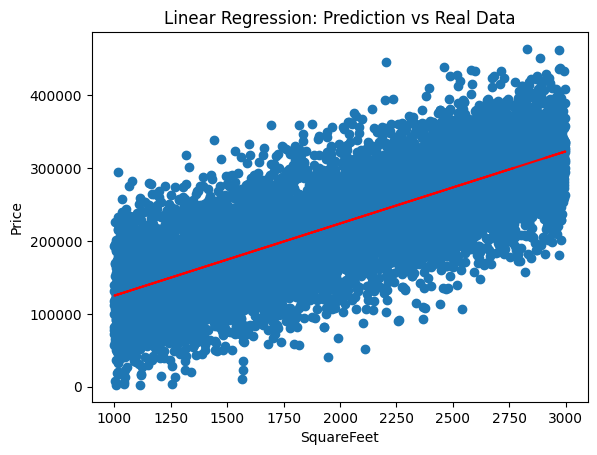

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color="red")
plt.xlabel("SquareFeet")
plt.ylabel("Price")
plt.title("Linear Regression: Prediction vs Real Data")
plt.show()

### Conclusion 

The selected model is too simple and underfitting.

From the graph:

There is a lot of scatter

A flat line just captures the "overall average"

There is a lot of error for small and large square footage

From the numbers:

R² ≈ 0.57
That means only ~57% of the price variation is explained

MAE ≈ 40,000
That means an average of $40,000 in error (which is a lot)

📌 The definitive conclusion:

Square footage alone is not enough for price

## Multiple Linear Regression

Why?

We still have no reason to reject linearity

We are just feeding the model a little information

What to do right now:

Add some logical and numeric columns

In [18]:
X = pd.get_dummies(
    df.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df['Price']
X.shape, y.shape

((49978, 6), (49978,))

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 39490.690345017865
R2: 0.5779866236606085


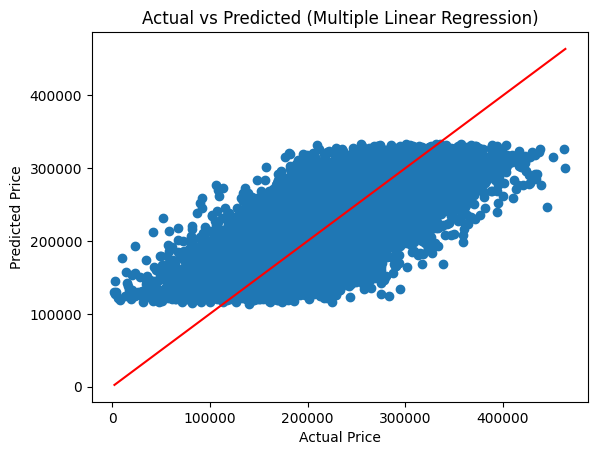

In [22]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Multiple Linear Regression)")
plt.show()

### Conclusion 

The selected model is too simple and underfitting.

From the numbers:
MAE ≈ 39k almost unchanged
R² ≈ 0.57 only slightly improved

From the Actual vs Predicted chart:
The points are “stretched”
Model:
Overestimates low prices
Underestimates high prices
That is, the model is pulling everything towards the “mean”


📌 This pattern has a specific name:

High Bias (Underfitting)

## Polynomial Linear Regression

In [23]:
X = df[["SquareFeet"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [25]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

In [26]:
print("Polynomial Regression (degree=2)")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Polynomial Regression (degree=2)
MAE: 39792.89662642617
R2: 0.5719094361907583


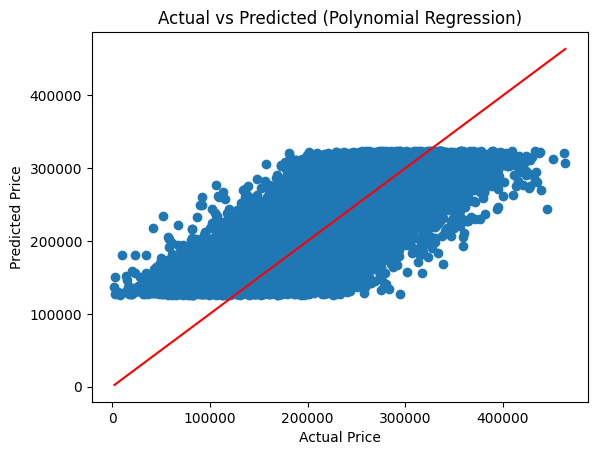

In [27]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.show()

### Conclusion


This chart is not the place to see “skewness” at all.

Why?

Because this chart is:
Actual vs Predicted
Not SquareFeet vs Price
Here:
X-axis = Actual Price
Y-axis = Predicted Price

So even if the skewness is learned:
It shows itself here as “getting closer to the 45 degree line”
Not as a curve
And as you saw:
Almost no improvement has occurred

## Feature Interaction

In [28]:
df_inter = df.copy()


df_inter["sqft_bedroom"] = df_inter["SquareFeet"] * df_inter["Bedrooms"]
df_inter["sqft_bathroom"] = df_inter["SquareFeet"] * df_inter["Bathrooms"]
df_inter["sqft_year"] = df_inter["SquareFeet"] * df_inter["YearBuilt"]

In [29]:
X = pd.get_dummies(
    df_inter.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df_inter["Price"]
X.shape, y.shape

((49978, 9), (49978,))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [32]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 39490.7858868637
R2: 0.5779557626837855


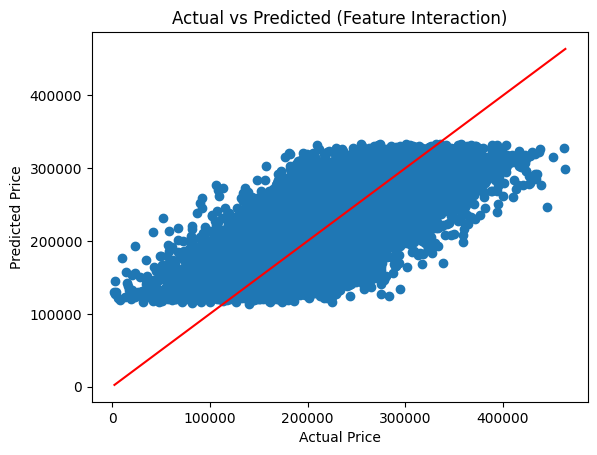

In [33]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Feature Interaction)")
plt.show()

### Conclusion

| Model                     | MAE    | R²    | Result     |
| ----------------------- | ------ | ----- | --------- |
| Linear              | ~39.6k | ~0.57 | underfit  |
| Multiple Linear         | ~39.4k | ~0.57 | |
| Polynomial (SquareFeet) | ~39.4k | ~0.57 | Ineffective    |
| Feature Interaction     | ~39.4k | ~0.57 | ‌Ineffective    |


📌 This means:

The problem is not solved with a straight line

Neither with a curve

Neither with a linear interaction of features

The name of this situation in ML is very specific:

**`Structural Underfitting`**

That is:

The structure of the model does not match the structure of the problem

## Decision Tree Regressor

In [34]:
X = pd.get_dummies(
    df.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df["Price"]
X.shape, y.shape

((49978, 6), (49978,))

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Decision Tree Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Decision Tree Regressor
MAE: 39668.84600115498
R2: 0.5739802334302244


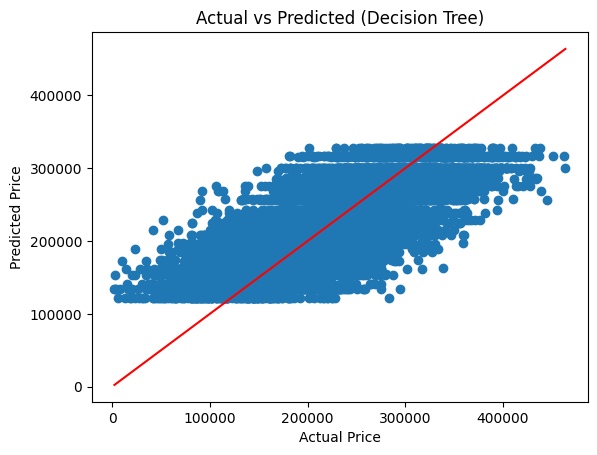

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()

### Conclusion

Numbers:
MAE ≈ 39.6k (almost the same)
R² ≈ 0.57 (even a little worse than best case)

Chart:
Still:

High prices ⇒ underestimate

Low prices ⇒ overestimate

The pull towards the mean is still there

The tree-like shape is visible but it didn't help

📌 The definitive result:

Even the conditional model failed to capture the structure of the problem

## Random Forest Regressor

In [40]:
X = pd.get_dummies(
    df.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df["Price"]
X.shape, y.shape

((49978, 6), (49978,))

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [43]:
y_pred = model.predict(X_test)

In [44]:
print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Random Forest Regressor
MAE: 39690.436887663425
R2: 0.573215295281158


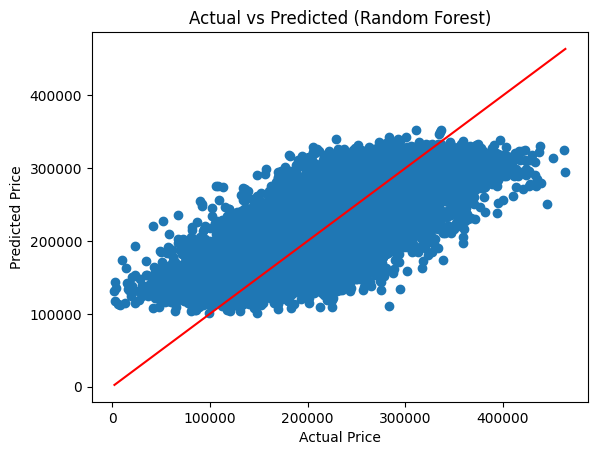

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

### Conclusion

RF result:

MAE ≈ 39.7k

R² ≈ 0.56

Not only did it not get better,
it even got slightly worse than the best linear case.

📌 This means:

This dataset has a data ceiling
and none of these models can learn more than this.

## Gradient Boosting Regressor

In [46]:
X = pd.get_dummies(
    df.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df["Price"]
X.shape, y.shape

((49978, 6), (49978,))

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = gbr.predict(X_test)

print("Gradient Boosting Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Gradient Boosting Regressor
MAE: 39496.32849592737
R2: 0.5775289974393987


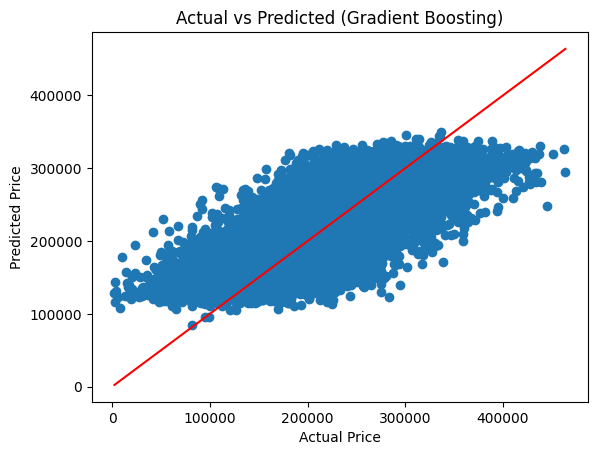

In [50]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

## CatBoost Regressor

In [51]:
# Install CatBoost only if your environment does not already have it:
# !pip install catboost

In [52]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "SquareFeet",
    "Bedrooms",
    "Bathrooms",
    "YearBuilt",
    "Neighborhood"
]

X = df[features]
y = df["Price"]

cat_features = ["Neighborhood"]


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MAE",
    random_seed=42,
    verbose=0
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=0)

In [55]:
y_pred = model.predict(X_test)

print("CatBoost Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

CatBoost Regressor
MAE: 39543.71477281717
R2: 0.5769689299785217


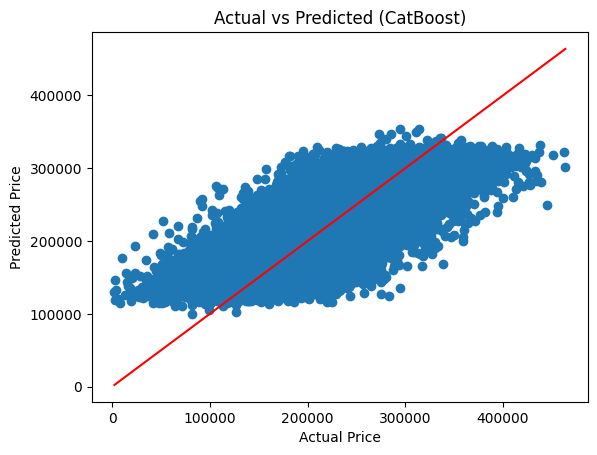

In [56]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (CatBoost)")
plt.show()


## MLPRegressor (Fully Connected NN)

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor

In [58]:
X = df.drop(columns=["Price"])
y = df["Price"]
X_encoded = pd.get_dummies(X, columns=["Neighborhood"], drop_first=True)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

model.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0005
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [62]:
y_pred = model.predict(X_test_scaled)

print("Neural Network (MLP)")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Neural Network (MLP)
MAE: 39633.65923825543
R2: 0.5751389024415188


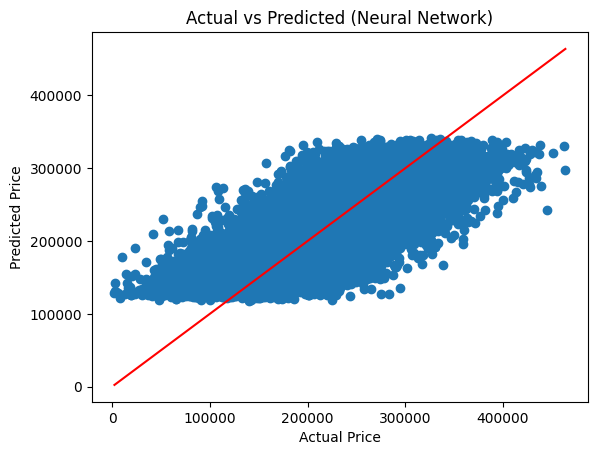

In [63]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Neural Network)")
plt.show()

## Model Comparison and Cross-Validation

This section compares the main models using the same encoded feature set and cross-validation. This gives a fairer comparison than relying only on one train/test split.


In [64]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

X = pd.get_dummies(
    df.drop(columns=["Price"]),
    columns=["Neighborhood"],
    drop_first=True
)
y = df["Price"]

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),
    "MLP Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            batch_size=64,
            learning_rate_init=0.001,
            max_iter=300,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        ))
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1
    )
    rows.append({
        "Model": name,
        "CV MAE Mean": -scores["test_mae"].mean(),
        "CV MAE Std": scores["test_mae"].std(),
        "CV R2 Mean": scores["test_r2"].mean(),
        "CV R2 Std": scores["test_r2"].std()
    })

comparison_df = pd.DataFrame(rows).sort_values("CV MAE Mean")
comparison_df

,Model,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,Linear Regression,39858.868812,368.110830,0.569713,0.007566
3,Gradient Boosting,39919.169316,373.576534,0.568380,0.007774
4,MLP Regressor,39964.588956,321.252521,0.567636,0.006956
1,Decision Tree,40068.100548,318.098364,0.564854,0.006933
2,Random Forest,40082.621251,338.212643,0.564514,0.007576


### Final Conclusion

After cleaning invalid target values and comparing models on the same encoded features, the best model should be selected based on the lowest cross-validated MAE and highest cross-validated R2. If the models still perform similarly, the result suggests that the available features explain only part of the house-price variation, so collecting stronger predictors may matter more than using a more complex algorithm.
